# mGPLVM analysis on recurrent units

In [2]:
import torch
import mgplvm as mgp
import numpy as np
import matplotlib.pyplot as plt
import pickle
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from scipy.stats import binned_statistic, pearsonr, ttest_1samp
import Rotations as Rot
import utils as u
from utils import goto_project_root
from utils.path_settings import MODEL_SAVE_PATH, DATA_PATH, LOG_PATH, CONFIG_PATH
from torch.utils.tensorboard import SummaryWriter
import SimulateDatasets.GenTrainingData as g
from utils import create_splits, get_dataloaders, force_remove_dir
from Network_models import Trainer as t
from importlib import reload

import plotly.graph_objects as go
import os
reload(t)
reload(g)
import time
reload(u)

plt.rcParams['font.size'] = 20
plt.rcParams['axes.spines.right'] = False
plt.rcParams[('axes.spines.top')] = False
device = mgp.utils.get_device()

loading


In [3]:
seed = 1000
np.random.seed(seed)
torch.manual_seed(seed)
trainer = u.load_trainer_model("FC_16_GRU_1layer_8hidden_0.1q_configs", None)
n_size = 8
configs = trainer.config
configs['training_config']['data_save_path'] = configs['training_config']['data_save_path'].strip(".pth") + "_mGPLVM.pth"

Using a scheduler


In [ ]:
print('hi')

## Create a function that generates a mGPLVM-suitable dataset

Credit: Kris's [Colab Notebook](https://colab.research.google.com/drive/1C7x5u4cMsH5f4i261Yz81zgDHgcJ-_MY?usp=sharing#scrollTo=_kLWsteXAb5z)

consecutive displacements: [0.37507251 0.77469937 1.40428099 2.15003666 2.73722506]


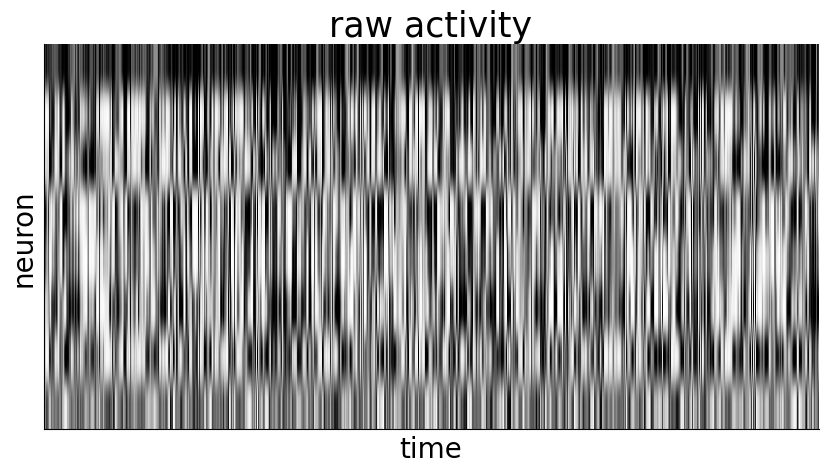

(1, 8, 800)


C:\Users\timmy\Documents\Projects_dir\Mental_Rotations\mental-rotations\mgplvm-Github\mgplvm\models\svgp.py:356: UserWarning: torch.cholesky is deprecated in favor of torch.linalg.cholesky and will be removed in a future PyTorch release.
L = torch.cholesky(A)
should be replaced with
L = torch.linalg.cholesky(A)
and
U = torch.cholesky(A, upper=True)
should be replaced with
U = torch.linalg.cholesky(A).mH
This transform will produce equivalent results for all valid (symmetric positive definite) inputs. (Triggered internally at ..\aten\src\ATen\native\BatchLinearAlgebra.cpp:1699.)
  l = torch.cholesky(kzz, upper=False)[None, ...]
C:\Users\timmy\Documents\Projects_dir\Mental_Rotations\mental-rotations\mgplvm-Github\mgplvm\models\svgp.py:269: UserWarning: torch.triangular_solve is deprecated in favor of torch.linalg.solve_triangularand will be removed in a future PyTorch release.
torch.linalg.solve_triangular has its arguments reversed and does not return a copy of one of the inputs.
X = to

iter   0 | elbo -15.780 | kl  0.084 | loss  15.780 | |mu| 0.500 | sig 1.500 | scale 1.000 | ell 2.000 | lik_sig 1.000 | brownian_c 0.000 | brownian_eta 4.000 |
iter 100 | elbo -1.221 | kl  0.062 | loss  1.274 | |mu| 0.500 | sig 1.475 | scale 1.044 | ell 1.914 | lik_sig 0.945 | brownian_c 0.000 | brownian_eta 0.582 |
iter 200 | elbo -0.961 | kl  0.067 | loss  1.027 | |mu| 0.500 | sig 1.399 | scale 0.931 | ell 2.029 | lik_sig 0.651 | brownian_c 0.000 | brownian_eta 0.639 |
iter 300 | elbo -0.846 | kl  0.080 | loss  0.926 | |mu| 0.500 | sig 1.334 | scale 0.751 | ell 2.201 | lik_sig 0.574 | brownian_c 0.000 | brownian_eta 0.664 |
iter 400 | elbo -0.789 | kl  0.090 | loss  0.879 | |mu| 0.500 | sig 1.275 | scale 0.616 | ell 2.321 | lik_sig 0.540 | brownian_c 0.000 | brownian_eta 0.665 |
iter 500 | elbo -0.753 | kl  0.101 | loss  0.854 | |mu| 0.500 | sig 1.253 | scale 0.530 | ell 2.399 | lik_sig 0.521 | brownian_c 0.000 | brownian_eta 0.683 |
iter 600 | elbo -0.724 | kl  0.115 | loss  0.839 |

<Figure size 640x480 with 0 Axes>

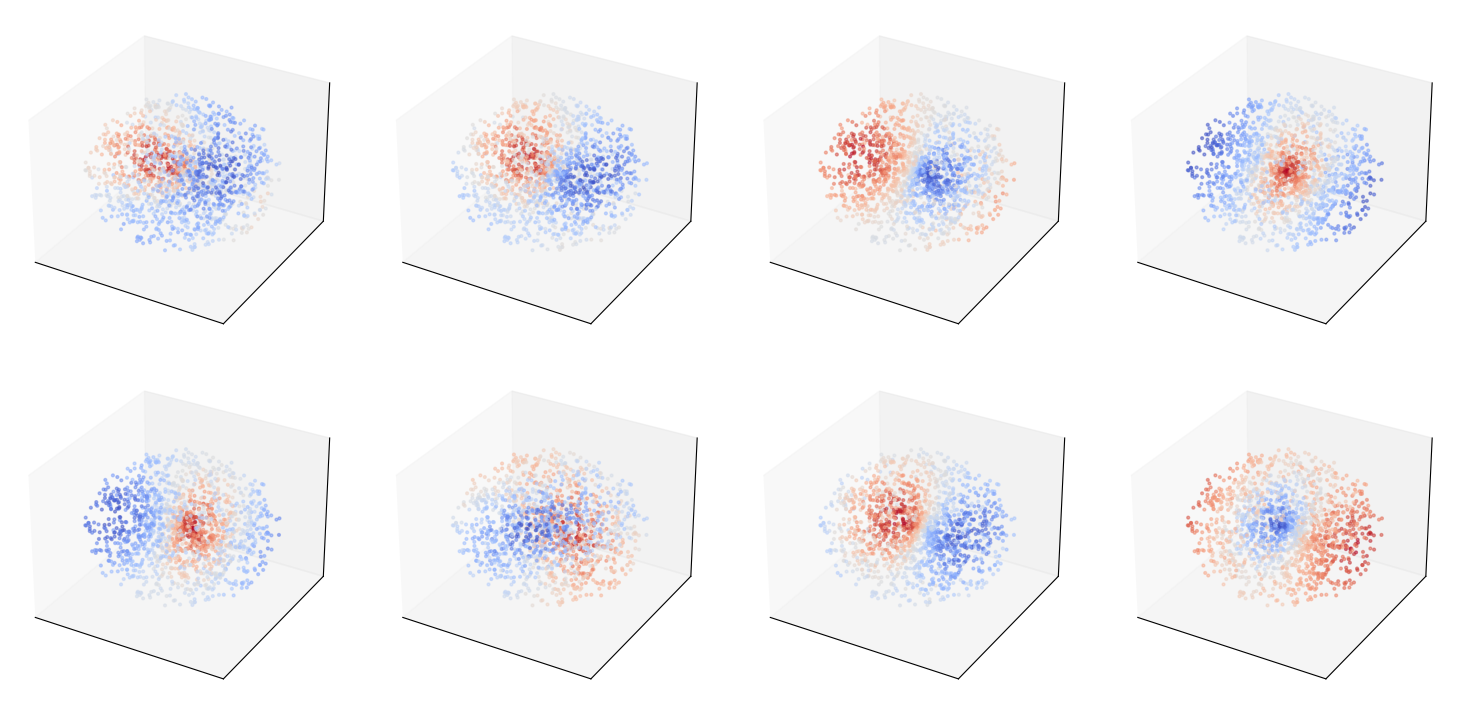

In [5]:
### Try SO(3) ###
reload(Rot)
### generate some synthetic data ###
def plot_activity_heatmap(Y, title = "raw activity"):
  ### plot the activity of our neurons ###
  plt.figure(figsize = (10, 5))
  plt.imshow(Y, cmap = 'Greys', aspect = 'auto', vmin = np.quantile(Y, 0.01), vmax = np.quantile(Y, 0.90))
  plt.xlabel('time')
  plt.ylabel('neuron')
  plt.title(title, fontsize = 25)
  plt.xticks([])
  plt.yticks([])
  plt.show()

n_ts = 800 #total time points
n_ts1 = 400 #training time points
n_neurons = 100 #number of neurons

#generate quaternions over time using an autoregressive process
qs_t = np.random.normal(0, 1, (n_ts, 4)) #random points on sphere
qs_t = qs_t / np.sqrt(np.sum(qs_t**2, axis = 1, keepdims = True)) #normalize
for t in range(1, n_ts): #autoregressive process
  step = np.random.normal(0, 0.4, 3) #displacement in tangent space
  theta = np.sqrt(np.sum(step**2))
  v = step / theta
  qt = np.concatenate([np.ones(1)*np.cos(theta), np.sin(theta)*v]) #displacement in quaternion space
  qs_t[t, :] = Rot.q_mult_np(qt, qs_t[t-1, :])
  #print(qs_t[t, :], np.sum(qs_t[t, :]**2), theta)
qs_t = np.sign(qs_t[:, :1]) * qs_t #consistent sign

dt_dists = 4*( 1 - np.sum(qs_t[:-1, :] * qs_t[1:, :], axis = 1)**2 )
print('consecutive displacements:', np.quantile(dt_dists, [0.1, 0.25, 0.5, 0.75, 0.9]))
reload(g)
reload(Rot)
device = "cuda"
data = g.gen_featured_data(qs_t, trainer.config['training_config'])
features, labels = data.data, data.labels
features = features.to(device)
labels = labels.to(device)
network_model = trainer.model.to(device)
network_model.eval()

def get_hidden_state(module, input, output):
    global hidden_states
    hidden_states.append(output[0].detach().clone())

network_model.rnn.register_forward_hook(get_hidden_state) 
hidden_states = []
out = network_model(features)
index = 49
plot_activity_heatmap(hidden_states[0][:, index, :].cpu().numpy().T)
Y = hidden_states[0][:, index, :].cpu().numpy().T
Y1 = hidden_states[0][:n_ts1, index, :].cpu().numpy().T
thetas1 = qs_t[:n_ts1, :]
Y2 = hidden_states[0][n_ts1:, index, :].cpu().numpy().T
Y = np.array([Y])
_, n, m = Y.shape
plt.figure()
Yplot = Y[0]
print(Y.shape)
d = 1  # dims of latent space
n_z = 15  # number of inducing points
n_samples = 1  # number of samples


def build_model():
    # specify manifold, kernel and rdist
    manif = mgp.manifolds.So3(m, d)  # latent distribution manifold
    lat_dist = mgp.rdist.ReLie(manif, m, n_samples)  # construct ReLie distribution
    # Note: we construct the kernel and likelihood by passing the data in for initialization
    kernel = mgp.kernels.QuadExp(
        n, manif.distance
    )  # Use an exponential quadratic (RBF) kernel
    lik = mgp.likelihoods.Gaussian(n)  # Gaussian likelihood
    #lprior = mgp.lpriors.Uniform(manif)  # Prior on the manifold distribution
    lprior = mgp.lpriors.Brownian(manif, fixed_brownian_c=True, fixed_brownian_eta=False,
                                  brownian_eta=torch.ones(d) * 2 ** 2)
    z = manif.inducing_points(n, n_z)  # build inducing points
    model = mgp.models.SvgpLvm(
        n, m, n_samples, z, kernel, lik, lat_dist, lprior, whiten=False #True
    ).to(device)
    return model


data = torch.tensor(Y, device=device, dtype=torch.get_default_dtype())
model = build_model()

train_params = mgp.crossval.training_params(max_steps=1500, n_mc=16, lrate=5e-2, print_every=100, burnin=50)
progress = mgp.crossval.train_model(model, data, train_params)  # train model
pickle.dump(model, open(configs['save_path'] + "\\best_model_mgplvm.pkl", "wb"))
n_ts = 1600  #total time points
n_ts1 = 400  #training time points
n_neurons = n_size  #number of neurons

#generate quaternions over time using an autoregressive process
qs_t = np.random.normal(0, 1, (n_ts, 4))  #random points on sphere
qs_t = qs_t / np.sqrt(np.sum(qs_t ** 2, axis=1, keepdims=True))  #normalize
for t in range(1, n_ts):  #autoregressive process
    step = np.random.normal(0, 0.4, 3)  #displacement in tangent space
    theta = np.sqrt(np.sum(step ** 2))
    v = step / theta
    qt = np.concatenate([np.ones(1) * np.cos(theta), np.sin(theta) * v])  #displacement in quaternion space
    qs_t[t, :] = Rot.q_mult_np(qt, qs_t[t - 1, :])

qs_t = np.sign(qs_t[:, :1]) * qs_t  #consistent sign

theta = 2 * np.arccos(qs_t[..., :1])
u = qs_t[..., 1:]

xs = (0.5 * 
      u * theta)

query = torch.tensor(qs_t.T,
                     dtype=torch.get_default_dtype(),
                     device=device)[None, None, ...]
data = torch.tensor(Y, dtype=torch.get_default_dtype()).to(device)
fmean, fvar = model.obs.predict(query, full_cov=False)
fstd = fvar.sqrt()
print('\n\ntuning curves:')
from mpl_toolkits import mplot3d

plt.figure(figsize=(15, 15*n_size / 16))
for i in range(n_size):
    mean, std = [arr.cpu().detach().numpy() for arr in [fmean, fstd]]
    mean = mean[0, 0, :, :]
    ax = plt.subplot(int(n_size/4), 4, i + 1, projection='3d')
    n = i
    ax.scatter3D(xs[:, 0], xs[:, 1], xs[:, 2], c=mean[n, :], cmap='coolwarm', alpha=0.5, s=4)
    ax.set_xticks([]);
    ax.set_yticks([]);
    ax.set_zticks([])
plt.tight_layout()
plt.savefig(configs['save_path'] + "\\best_model_tuning_curves_mgplvm.png")

# Assuming you have already defined xs, fmean, and fstd appropriately

# Extract mean values
mean = fmean.cpu().detach().numpy()[0, 0, :, :]

# Create a figure with subplots
fig = go.Figure()
for i in range(n_size):
    n = i
    fig.add_trace(go.Scatter3d(
        x=xs[:, 0],
        y=xs[:, 1],
        z=xs[:, 2],
        mode='markers',
        marker=dict(
            size=4,
            reversescale=True,
            color=mean[n, :],
            opacity=0.8,
            colorbar=dict(
                title='Mean Value',
                tickvals=[mean[n, :].min(), 0, mean[n, :].max()],
                ticktext=[f"Low: {min(mean[n, :]):.3g}", f"Medium: {0}", f"High: {max(mean[n, :]):.3g}"],
            ),
            colorbar_title='Mean Value',
            colorscale="rdbu"
        ),
        name=f'Tuning Curve {i + 1}',
        showlegend=False,
        visible=False,
    ))

# Update layout for each subplot
fig.update_layout(
    height=800,  # Adjust height to match your matplotlib figsize
    width=800,  # Adjust width to match your matplotlib figsize
    title='Tuning Curves',
    legend=dict(
        title='Tuning Curves',
        x=0.7,
        y=1.2
    ),
    scene=dict(
        xaxis=dict(title='X Axis'),
        yaxis=dict(title='Y Axis'),
        zaxis=dict(title='Z Axis')
    ),
    scene2=dict(
        xaxis=dict(title='X Axis'),
        yaxis=dict(title='Y Axis'),
        zaxis=dict(title='Z Axis')
    ),
    scene3=dict(
        xaxis=dict(title='X Axis'),
        yaxis=dict(title='Y Axis'),
        zaxis=dict(title='Z Axis')
    ),
    scene4=dict(
        xaxis=dict(title='X Axis'),
        yaxis=dict(title='Y Axis'),
        zaxis=dict(title='Z Axis')
    ),
    scene5=dict(
        xaxis=dict(title='X Axis'),
        yaxis=dict(title='Y Axis'),
        zaxis=dict(title='Z Axis')
    ),
    scene6=dict(
        xaxis=dict(title='X Axis'),
        yaxis=dict(title='Y Axis'),
        zaxis=dict(title='Z Axis')
    ),
    scene7=dict(
        xaxis=dict(title='X Axis'),
        yaxis=dict(title='Y Axis'),
        zaxis=dict(title='Z Axis')
    )
)
fig.data[0].visible = True
# Create update menu buttons
updatemenus = [
    dict(
        type="buttons",
        showactive=False,
        buttons=[
            dict(label=f'Tuning Curve {i + 1}',
                 method='update',
                 args=[{'visible': [j == i for j in range(8)]}])
            for i in range(8)
        ],
    )
]

# Update layout for each subplot
fig.update_layout(
    updatemenus=updatemenus,
    height=800,  # Adjust height to match your matplotlib figsize
    width=800,  # Adjust width to match your matplotlib figsize
    title='Tuning Curves',
    legend=dict(
        title='Tuning Curves',
        x=0.7,
        y=1.2
    ),
    scene=dict(
        xaxis=dict(title='X Axis'),
        yaxis=dict(title='Y Axis'),
        zaxis=dict(title='Z Axis')
    )
)
pickle.dump(fig, open(configs['save_path'] + "\\best_model_tuning_curves_mgplvm.pkl", "wb"))
fig.show()

In [5]:
fig = pickle.load(open(configs['save_path'] + "\\best_model_tuning_curves_Ground_Truth.pkl", "rb"))
fig.show()

FileNotFoundError: [Errno 2] No such file or directory: 'D:\\Projects\\mental-rotations\\models\\FC_16_GRU_1layer_8hidden_0.1q_model_gradual_constant\\best_model_tuning_curves_Ground_Truth.pkl'

In [ ]:
#generate quaternions over time using an autoregressive process
qs_t = np.random.normal(0, 1, (n_ts, 4))  #random points on sphere
qs_t = qs_t / np.sqrt(np.sum(qs_t ** 2, axis=1, keepdims=True))  #normalize
for t in range(1, n_ts):  #autoregressive process
    step = np.random.normal(0, 0.4, 3)  #displacement in tangent space
    theta = np.sqrt(np.sum(step ** 2))
    v = step / theta
    qt = np.concatenate([np.ones(1) * np.cos(theta), np.sin(theta) * v])  #displacement in quaternion space
    qs_t[t, :] = Rot.q_mult_np(qt, qs_t[t - 1, :])

qs_t = np.sign(qs_t[:, :1]) * qs_t  #consistent sign
# transform these quats into appropriate model inputs
# reload(g)
reload(Rot)
device = "cuda"
data = g.gen_featured_data(qs_t, trainer.config['training_config'])
features, labels = data.data, data.labels
features = features.to(device)
labels = labels.to(device)
network_model = trainer.model.to(device)
network_model.eval()

def get_hidden_state(module, input, output):
    global hidden_states
    hidden_states.append(output[0].detach().clone())

network_model.rnn.register_forward_hook(get_hidden_state) 
hidden_states = []
out = network_model(features)
index = 49
Y = hidden_states[0][:, index, :].cpu().numpy().T  
theta = 2 * np.arccos(qs_t[..., :1])
u = qs_t[..., 1:]
xs = 0.5 * u * theta

print('\n\ntuning curves:')

plt.figure(figsize=(15, 15 * n_size/16))
for i in range(n_size):
    # mean, std = [arr.cpu().detach().numpy() for arr in [fmean, fstd]]
    # mean = mean[0, 0, :, :]
    mean = Y[:, :]
    ax = plt.subplot(int(n_size/4), 4, i + 1, projection='3d')
    n = i
    ax.scatter3D(xs[:, 0], xs[:, 1], xs[:, 2], c=mean[n, :], cmap='coolwarm', alpha=0.5, s=4)
    ax.set_xticks([]);
    ax.set_yticks([]);
    ax.set_zticks([])
plt.tight_layout()
plt.savefig(configs['save_path'] + "\\best_model_tuning_curves_Ground_Truth.png")

# Assuming you have already defined xs, fmean, and fstd appropriately

# Extract mean values
mean = Y[:, :]

# Create a figure with subplots
fig = go.Figure()
for i in range(n_size):
    n = i
    fig.add_trace(go.Scatter3d(
        x=xs[:, 0],
        y=xs[:, 1],
        z=xs[:, 2],
        mode='markers',
        marker=dict(
            size=4,
            reversescale=True,
            color=mean[n, :],
            opacity=0.8,
            colorbar=dict(
                title='Mean Value',
                tickvals=[mean[n, :].min(), 0, mean[n, :].max()],
                ticktext=[f"Low: {min(mean[n, :]):.3g}", f"Medium: {0}", f"High: {max(mean[n, :]):.3g}"],
            ),
            colorbar_title='Mean Value',
            colorscale="rdbu"
        ),
        name=f'Tuning Curve {i + 1}',
        showlegend=False,
        visible=False,
    ))

# Update layout for each subplot
fig.update_layout(
    height=800,  # Adjust height to match your matplotlib figsize
    width=800,  # Adjust width to match your matplotlib figsize
    title='Tuning Curves',
    legend=dict(
        title='Tuning Curves',
        x=0.7,
        y=1.2
    ),
    scene=dict(
        xaxis=dict(title='X Axis'),
        yaxis=dict(title='Y Axis'),
        zaxis=dict(title='Z Axis')
    ),
    scene2=dict(
        xaxis=dict(title='X Axis'),
        yaxis=dict(title='Y Axis'),
        zaxis=dict(title='Z Axis')
    ),
    scene3=dict(
        xaxis=dict(title='X Axis'),
        yaxis=dict(title='Y Axis'),
        zaxis=dict(title='Z Axis')
    ),
    scene4=dict(
        xaxis=dict(title='X Axis'),
        yaxis=dict(title='Y Axis'),
        zaxis=dict(title='Z Axis')
    ),
    scene5=dict(
        xaxis=dict(title='X Axis'),
        yaxis=dict(title='Y Axis'),
        zaxis=dict(title='Z Axis')
    ),
    scene6=dict(
        xaxis=dict(title='X Axis'),
        yaxis=dict(title='Y Axis'),
        zaxis=dict(title='Z Axis')
    ),
    scene7=dict(
        xaxis=dict(title='X Axis'),
        yaxis=dict(title='Y Axis'),
        zaxis=dict(title='Z Axis')
    )
)
fig.data[0].visible = True
# Create update menu buttons
updatemenus = [
    dict(
        type="buttons",
        showactive=False,
        buttons=[
            dict(label=f'Tuning Curve {i + 1}',
                 method='update',
                 args=[{'visible': [j == i for j in range(8)]}])
            for i in range(8)
        ],
    )
]

# Update layout for each subplot
fig.update_layout(
    updatemenus=updatemenus,
    height=800,  # Adjust height to match your matplotlib figsize
    width=800,  # Adjust width to match your matplotlib figsize
    title='Tuning Curves',
    legend=dict(
        title='Tuning Curves',
        x=0.7,
        y=1.2
    ),
    scene=dict(
        xaxis=dict(title='X Axis'),
        yaxis=dict(title='Y Axis'),
        zaxis=dict(title='Z Axis')
    )
)
pickle.dump(fig, open(configs['save_path'] + "\\best_model_tuning_curves_Ground_Truth.pkl", "wb"))
fig.show()

In [ ]:
def plot_activity_heatmap(Y, title = "raw activity"):
  ### plot the activity of our neurons ###
  plt.figure(figsize = (10, 5))
  plt.imshow(Y, cmap = 'Greys', aspect = 'auto', vmin = np.quantile(Y, 0.01), vmax = np.quantile(Y, 0.90))
  plt.xlabel('time')
  plt.ylabel('neuron')
  plt.title(title, fontsize = 25)
  plt.xticks([])
  plt.yticks([])
  plt.show()

def plot_tuning_curves(fit_thetas, ys_noise, plot_thetas, ys_lin, ys_bins, ys_gp, xs_bins):
  plt.figure(figsize = (5,3.0))
  plt.scatter(fit_thetas, ys_noise, color = "k", alpha = 0.2)
  plt.plot(plot_thetas, ys_lin, 'b-', label = 'linear')
  plt.plot(xs_bins, ys_bins, 'g-', label = 'binned')
  plt.plot(plot_thetas, ys_gp, 'm-', label = 'GP')
  plt.legend(frameon = False, ncol = 3, loc = 'upper center', bbox_to_anchor = [0.5, 1.4])
  plt.xlim(0, 2*np.pi)
  plt.xlabel('theta')
  plt.ylabel('activity')
  plt.yticks([])
  plt.xticks([0, np.pi, 2*np.pi], [r'$0$', r'$\pi$', r'$2 \pi$'])
  plt.show()

def cb(mod, i, loss):
  """here we construct an (optional) function that helps us keep track of the training"""
  if i in [0, 50, 100, 150, 300, 500, 1000, 1500, 1999]: #iterations to plot
    X = mod.lat_dist.prms[0].detach().cpu().numpy()[0, ...]
    X = X % (2*np.pi)
    plt.figure(figsize = (4,4))
    plt.xlim(0, 2*np.pi); plt.ylim(0, 2*np.pi)
    plt.xlabel("true latents"); plt.ylabel("model latents")
    plt.scatter(thetas_plot, X[:, 0], color = 'k')
    plt.title('iter = '+str(i))
    plt.show()
    print(mod.lat_dist.msg(None, None, None) + mod.svgp.msg + mod.lprior.msg, loss/n_ts1)

def cb_tun(mod, i, loss):
  if i in [0, 50, 100, 150, 300, 500, 1000, 1500, 1999]: #iterations to plot
    query = np.linspace(0,2*np.pi, 101)
    query_pytorch = torch.tensor(query, dtype=torch.get_default_dtype()).to(device)[None, None, ...] #reformat for pytorch
    samples = mod.obs.sample(query_pytorch, 50, noise = False)
    fmean = samples.mean(0).detach().cpu().numpy()[0, ...] #find the mean
    plt.figure(figsize=(6, 4))
    inds = [1, 10, 5] #example neurons to plot
    for ind in inds:
      samp = 15
      plt.plot(query, fmean[ind, :], lw = 4)
      plt.scatter(z1[::samp], Y1[ind, ::samp])
    plt.xlabel(r"$\theta$")
    plt.xticks([0, np.pi, 2*np.pi], [r'$0$', r'$\pi$', r'$2 \pi$'])
    plt.ylabel("firing rate")
    plt.yticks([])
    plt.xlim(0, 2*np.pi)
    plt.title('iter = '+str(i))
    plt.show()
    print(mod.lat_dist.msg(None, None, None) + mod.svgp.msg + mod.lprior.msg, loss/n_ts1)

def plot_final_thetas(thetas2, thetas2_lin, thetas2_mgplvm):
  plt.figure()
  plt.scatter(thetas2, thetas2_lin, color = "b")
  plt.scatter(thetas2, thetas2_mgplvm, color = "k")
  plt.legend(['linear', 'mgplvm'], frameon = False, ncol = 2, loc = 'upper center', bbox_to_anchor = (0.5, 1.25))
  plt.xlabel('true theta')
  plt.ylabel('predicted theta')
  plt.show()

def plot_final_errors(errs_lin, errs_mgplvm, bins):
  plt.figure()
  plt.hist(errs_lin, bins = bins, color = 'b', alpha = 0.2)
  plt.hist(errs_mgplvm, bins = bins, color = 'k', alpha = 0.2)
  plt.axvline(np.mean(errs_lin), color = 'b', lw = 3)
  plt.axvline(np.mean(errs_mgplvm), color = 'k', lw = 3)
  plt.xlabel('error')
  plt.ylabel('frequency')
  plt.legend(['linear', 'mgplvm'], frameon = False)
  plt.show()

def plot_hd_by_time(ts, z, title = None):
  plt.figure()
  plt.scatter(ts-ts[0], z, color = 'k', s = 5)
  plt.xlabel('time (s)')
  plt.ylabel('head direction')
  plt.yticks([0, np.pi, 2*np.pi], [r'$0$', r'$\pi$', r'$2 \pi$'])
  plt.xlim(0, ts[-1]-ts[0])
  plt.ylim(0, 2*np.pi)
  plt.title(title)
  plt.show()

In [ ]:
### set some parameters for fitting ###
max_steps = 1501 # number of training iterations
n_mc = 1 # number of monte carlo samples per iteration (since the latents are a delta function, we only need 1)
print_every = 100 # how often we print training progress
d_latent = 3 # specify the dimensionality of the space
n_z = 15 #number of inducing points; performance increases with more inducing points
n_trials = 1

### construct the actual model ###
n_neurons, n_ts1 = Y1.shape
data1 = torch.Tensor(Y1[None, ...]).to(device)

manif = mgp.manifolds.So3(n_ts1, d_latent) # our latent variables live on SO(3) (see Jensen et al. 2020 for alternatives)
likelihood = mgp.likelihoods.Gaussian(n_neurons, Y = Y1[None, ...], d = d_latent) #Gaussian noise
mu = qs_t[None, :n_ts1, :] #ground truth thetas for training
lat_dist = mgp.rdist.ReLie(manif, n_ts1, n_trials, sigma = 1e-5, diagonal = False, mu = mu) #latent distribution

#learn the prior!
lprior = mgp.lpriors.Brownian(manif, fixed_brownian_c = True, fixed_brownian_eta = False, brownian_eta = torch.ones(d_latent)*0.5**2)

kernel = mgp.kernels.QuadExp(n_neurons, manif.distance, Y = Y1[None, ...], ell = np.ones(n_neurons)*1.0, scale = 0.7*np.ones(n_neurons)) #squared exponential kernel
z = manif.inducing_points(n_neurons, n_z) #inducing points
mod = mgp.models.SvgpLvm(n_neurons, n_ts1, n_trials, z, kernel, likelihood, lat_dist, lprior).to(device) #construct model

In [ ]:
def cb_so3(mod, i, loss):
  """here we construct an (optional) function that helps us keep track of the training"""
  if i in [0, 50, 100, 150, 250, 350, 500, 750, 1000, 1250, 1500, 1999]: #iterations to plot
    print(i, mod.lat_dist.msg(Y, None, None) + mod.svgp.msg + mod.lprior.msg, loss/n_ts1)

train_params = mgp.crossval.training_params(max_steps = max_steps, n_mc = n_mc, lrate = 5e-2, callback = cb_so3, print_every = 10000, burnin = 50, mask_Ts = (lambda x: x*0))
print('fitting', n_neurons, 'neurons and', n_ts1, 'time bins for', max_steps, 'iterations')
mod_train = mgp.crossval.train_model(mod, data1, train_params)

In [ ]:
## first fit a linear model (we will use this for initialization and comparison) ##
Y2 = Y[..., n_ts1:] #test data
Z1, Z2 = qs_t[:n_ts1, :], qs_t[n_ts1:, :] #train/test quaternions
print(Y1.shape, Z1.shape)

alphas = 10**(np.linspace(-4, 4, 51)) #possible regularization strengths
clf = RidgeCV(alphas=alphas).fit(Y1.T, Z1) #crossvalidated ridge regression
Z2_pred = clf.predict(Y2.T) #predict test data
Z2_pred = Z2_pred / np.sqrt(np.sum(Z2_pred**2, axis = 1, keepdims = True)) #normalize
Z2_pred = np.sign(Z2_pred[:, :1]) * Z2_pred

errs_lin = 4*( 1 - np.sum(Z2 * Z2_pred, axis = 1)**2 )
errs_baseline = 4*( 1 - np.sum(np.array([1,0,0,0])[None, :] * Z2, axis = 1)**2 )
errs_baseline = deltas.flatten()

print('linear error:', np.quantile(errs_lin, [0.1, 0.25, 0.5, 0.75, 0.9]))
print('baseline/constant:', np.quantile(errs_baseline, [0.1, 0.25, 0.5, 0.75, 0.9]))

In [ ]:
### now we want to do decoding ###
_, n_ts2 = Y2.shape
manif2 = mgp.manifolds.So3(n_ts2, d_latent) # latent manifold is still So(3)
mu2 = Z2_pred[None, ...] #initialize from linear prediction
lat_dist2 = mgp.rdist.ReLie(manif2, n_ts2, n_trials, sigma = 0.4, diagonal = False, mu = mu2) #variational distribution
#in this case we do not define a new prior

In [ ]:
#@title Construct SO(3) model

data2 = torch.Tensor(Y2[None, ...]).to(device) #put data on device
mod2 = mgp.models.SvgpLvm(n_neurons, n_ts2, n_trials, z.cpu(), kernel.cpu(), likelihood.cpu(), lat_dist2, lprior.cpu()).to(device) #use old generative model and new variational distribution
for p in mod2.parameters():  #no gradients for generative parameters
  p.requires_grad = False
for p in mod2.lat_dist.parameters(): #only inference
  p.requires_grad = True
#copy over tuning curves (this summarizes p(Y*|Z*, {Y, Z}) from the training data in the SVGP framework)
mod2.svgp.q_mu[...] = mod.svgp.q_mu[...].detach()
mod2.svgp.q_sqrt[...] = mod.svgp.q_sqrt[...].detach()

In [ ]:
train_params2 = mgp.crossval.training_params(max_steps = max_steps, n_mc = 30, lrate = 2.5e-2, print_every = 10000, callback = cb_so3, burnin = 1, mask_Ts = (lambda x: x*1))
print('fitting', n_neurons, 'neurons and', n_ts2, 'time bins for', max_steps, 'iterations')
mod_train2 = mgp.crossval.train_model(mod2, data2, train_params2) #inference!

In [ ]:
Z2_mgplvm = mod2.lat_dist.prms[0].detach().cpu().numpy()[0, ...] #mgplvm prediction
print(Z2_mgplvm.shape)

errs_mgplvm = 4*( 1 - np.sum(Z2 * Z2_mgplvm, axis = 1)**2 )

cols = ['g', 'b', 'k']
bins = np.linspace(0, np.pi, 11)
#bins = np.linspace(0, np.pi**2, 11)
plt.figure()
labels = ['constant', 'linear', 'mgplvm']
for idat, dat in enumerate([errs_baseline, errs_lin, errs_mgplvm]):
  dat = np.arccos( 1 - 0.5*dat)
  #dat = dat**2
  plt.hist(dat, bins = bins, alpha = 0.3, color = cols[idat], density = True,
           histtype = ('step' if idat == 0 else 'bar'), lw = 5, label = labels[idat])
  plt.axvline(np.mean(dat), color = cols[idat], lw = 4)
  print(labels[idat]+' mean error:', np.mean(dat))
plt.xlabel('geodesic error')
plt.ylabel('frequency')
plt.yticks([])
plt.xticks([0, np.pi/2, np.pi], [r'$0$', r'$\pi / 2$', r'$\pi$'])
plt.legend(frameon = False, loc = 'upper center', bbox_to_anchor = (0.5, 1.2), ncol = 3, fontsize = 16)
plt.show()

In [ ]:
Y = np.array([Y])
_, n, m = Y.shape
plt.figure()
Yplot = Y[0]
plt.imshow(Yplot, cmap='Greys', aspect='auto', origin = 'upper')
plt.xlabel("time [a.u.]")
plt.ylabel("neuron")
plt.xlim(0,500)
plt.ylim(-0.5,n-0.5)
plt.show()
plt.close()

In [ ]:
print(Y.shape)

In [ ]:
d = 1  # dims of latent space
n_z = 15  # number of inducing points
n_samples = 1  # number of samples
def build_model():
    # specify manifold, kernel and rdist
    manif = mgp.manifolds.So3(m, d)  # latent distribution manifold
    lat_dist = mgp.rdist.ReLie(manif, m, n_samples)  # construct ReLie distribution
    # Note: we construct the kernel and likelihood by passing the data in for initialization
    kernel = mgp.kernels.QuadExp(
        n, manif.distance
    )  # Use an exponential quadratic (RBF) kernel
    lik = mgp.likelihoods.Gaussian(n)  # Gaussian likelihood
    #lprior = mgp.lpriors.Uniform(manif)  # Prior on the manifold distribution
    lprior = mgp.lpriors.Brownian(manif, fixed_brownian_c = True, fixed_brownian_eta = False, brownian_eta = torch.ones(d)*2**2)
    z = manif.inducing_points(n, n_z)  # build inducing points
    model = mgp.models.SvgpLvm(
        n, m, n_samples, z, kernel, lik, lat_dist, lprior, whiten=True
    ).to(device)
    return model
data = torch.tensor(Y, device=device, dtype=torch.get_default_dtype())
model = build_model()

train_params = mgp.crossval.training_params(max_steps = 1500, n_mc = 16, lrate = 5e-2, print_every = 100, burnin = 50)
progress = mgp.crossval.train_model(model, data, train_params) # train model

In [ ]:
pickle.dump(model, open(configs['save_path']+ "\\best_model_mgplvm.pkl", "wb"))
n_ts = 1600 #total time points
n_ts1 = 400 #training time points
n_neurons = 100 #number of neurons

#generate quaternions over time using an autoregressive process
qs_t = np.random.normal(0, 1, (n_ts, 4)) #random points on sphere
qs_t = qs_t / np.sqrt(np.sum(qs_t**2, axis = 1, keepdims = True)) #normalize
for t in range(1, n_ts): #autoregressive process
  step = np.random.normal(0, 0.4, 3) #displacement in tangent space
  theta = np.sqrt(np.sum(step**2))
  v = step / theta
  qt = np.concatenate([np.ones(1)*np.cos(theta), np.sin(theta)*v]) #displacement in quaternion space
  qs_t[t, :] = Rot.q_mult_np(qt, qs_t[t-1, :])
  
qs_t = np.sign(qs_t[:, :1]) * qs_t #consistent sign

theta = 2 * np.arccos(qs_t[..., :1])
u = qs_t[..., 1:]
xs = 0.5 * u * theta

query = torch.tensor(qs_t.T,
                     dtype=torch.get_default_dtype(),
                     device=device)[None, None, ...]
data = torch.tensor(Y, dtype=torch.get_default_dtype()).to(device)
fmean, fvar = model.obs.predict(query, full_cov=False)
fstd = fvar.sqrt()

print('\n\ntuning curves:')
from mpl_toolkits import mplot3d
plt.figure(figsize = (15,7))
for i in range(8):
  mean, std = [arr.cpu().detach().numpy() for arr in [fmean, fstd]]
  mean = mean[0, 0, :, :]
  ax = plt.subplot(2, 4, i+1, projection='3d')
  n = i
  ax.scatter3D(xs[:, 0], xs[:, 1], xs[:,2], c = mean[n, :], cmap = 'coolwarm', alpha = 0.5, s = 4)
  ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
plt.tight_layout()
plt.savefig(configs['save_path'] + "\\best_model_tuning_curves.png")

In [ ]:

# Assuming you have already defined xs, fmean, and fstd appropriately

# Extract mean values
mean = fmean.cpu().detach().numpy()[0, 0, :, :]

# Create a figure with subplots
fig = go.Figure()
for i in range(8):
    n = i
    fig.add_trace(go.Scatter3d(
        x=xs[:, 0],
        y=xs[:, 1],
        z=xs[:, 2],
        mode='markers',
        marker=dict(
            size=4,
            reversescale = True,
            color=mean[n, :],
            opacity=0.8,
            colorbar=dict(
                title='Mean Value', 
                tickvals = [mean[n, :].min(), 0, mean[n, :].max()],
                ticktext = [f"Low: {min(mean[n, :]):.3g}", f"Medium: {0}", f"High: {max(mean[n, :]):.3g}"],
            ),
            colorbar_title='Mean Value',
            colorscale = "rdbu"
        ),
        name=f'Tuning Curve {i+1}',
        showlegend = False,
        visible = False,
    ))

# Update layout for each subplot
fig.update_layout(
    height=800,  # Adjust height to match your matplotlib figsize
    width=800,   # Adjust width to match your matplotlib figsize
    title='Tuning Curves',
    legend = dict(
        title = 'Tuning Curves',
        x = 0.7,
        y = 1.2
    ),
    scene=dict(
        xaxis=dict(title='X Axis'),
        yaxis=dict(title='Y Axis'),
        zaxis=dict(title='Z Axis')
    ),
    scene2=dict(
        xaxis=dict(title='X Axis'),
        yaxis=dict(title='Y Axis'),
        zaxis=dict(title='Z Axis')
    ),
    scene3=dict(
        xaxis=dict(title='X Axis'),
        yaxis=dict(title='Y Axis'),
        zaxis=dict(title='Z Axis')
    ),
    scene4=dict(
        xaxis=dict(title='X Axis'),
        yaxis=dict(title='Y Axis'),
        zaxis=dict(title='Z Axis')
    ),
    scene5=dict(
        xaxis=dict(title='X Axis'),
        yaxis=dict(title='Y Axis'),
        zaxis=dict(title='Z Axis')
    ),
    scene6=dict(
        xaxis=dict(title='X Axis'),
        yaxis=dict(title='Y Axis'),
        zaxis=dict(title='Z Axis')
    ), 
    scene7=dict(
        xaxis=dict(title='X Axis'),
        yaxis=dict(title='Y Axis'),
        zaxis=dict(title='Z Axis')
    )
)
fig.data[0].visible = True
# Create update menu buttons
updatemenus = [
    dict(
        type="buttons",
        showactive=False,
        buttons=[
            dict(label=f'Tuning Curve {i+1}',
                 method='update',
                 args=[{'visible': [j == i for j in range(8)]}]) 
            for i in range(8)
        ],
    )
]

# Update layout for each subplot
fig.update_layout(
    updatemenus=updatemenus,
    height=800,  # Adjust height to match your matplotlib figsize
    width=800,   # Adjust width to match your matplotlib figsize
    title='Tuning Curves',
    legend=dict(
        title='Tuning Curves',
        x=0.7,
        y=1.2
    ),
    scene=dict(
        xaxis=dict(title='X Axis'),
        yaxis=dict(title='Y Axis'),
        zaxis=dict(title='Z Axis')
    )
)
pickle.dump(fig, open(configs['save_path'] + "\\best_model_tuning_curves.pkl", "wb"))
fig.show()

In [ ]:
configs['save_path']